# **Partie 1**

**importation de DATA SET**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("TP PARTIE 1 — STATISTIQUES ET LOI NORMALE EN FINANCE")
print("Analyse risque portefeuille et calcul VaR")
print("="*80)

TP PARTIE 1 — STATISTIQUES ET LOI NORMALE EN FINANCE
Analyse risque portefeuille et calcul VaR


In [8]:
# Rendements mensuels historiques (%)
rendements_A = np.array([
    1.2, 0.8, -0.5, 1.5, 0.9, 1.1, 0.7, 1.3, 1.0, 0.6, 1.4, 0.8,
    1.1, 0.9, -0.3, 1.2, 1.0, 1.5, 0.8, 1.3, 0.9, 1.1, 1.2, 1.0
])

rendements_B = np.array([
    4.5, -2.1, 6.2, -3.5, 5.8, 7.1, -1.8, 4.9, 3.2, -4.2, 8.5, -2.7,
    5.1, 6.8, -3.1, 7.3, 4.5, -2.9, 6.7, 5.3, -3.8, 7.9, 4.2, 5.5
])

# Paramètres
capital = 500000 # € à investir
perte_max_toleree = 50000 # € (10% capital)
taux_sans_risque = 3.0 # % annuel

**QUESTION 1.1 — STATISTIQUES DESCRIPTIVES**

In [11]:
print("\n" + "="*80)
print("QUESTION 1.1 — STATISTIQUES DESCRIPTIVES")
print("="*80)

def calculer_stats_portefeuille(rendements, nom):
    """
    Calcule statistiques descriptives portefeuille

    Parameters:
        rendements : np.array Rendements mensuels (%)
        nom : str Nom portefeuille
    Returns:
        dict : Statistiques calculées
    """
    # a) Moyenne mensuelle
    moyenne_mensuelle = np.mean(rendements)

    # b) Écart-type mensuel
    ecart_type_mensuel = np.std(rendements, ddof=1) # ddof=1 pour échantillon

    # c) Médiane
    mediane = np.median(rendements)

    # d) Rendement annualisé (capitalisation composée)
    # Formule : (1 + r_mensuel/100)^12 - 1
    rendement_annuel = ((1 + moyenne_mensuelle/100)**12 - 1) * 100

    # e) Volatilité annualisée
    # Formule : σ_annuel = σ_mensuel × √12
    volatilite_annuelle = ecart_type_mensuel * np.sqrt(12)

    stats = {
        'nom': nom,
        'moyenne_mensuelle': moyenne_mensuelle,
        'ecart_type_mensuel': ecart_type_mensuel,
        'mediane': mediane,
        'rendement_annuel': rendement_annuel,
        'volatilite_annuelle': volatilite_annuelle
    }

    return stats

# Calcul stats pour les deux portefeuilles
stats_A = calculer_stats_portefeuille(rendements_A, "CONSERVATIVE (A)")
stats_B = calculer_stats_portefeuille(rendements_B, "AGRESSIF (B)")

# Affichage résultats
for stats in [stats_A, stats_B]:
    print(f"\n📊 PORTEFEUILLE {stats['nom']}")
    print(f"\t• Rendement mensuel moyen : {stats['moyenne_mensuelle']:.2f}%")
    print(f"\t• Écart-type mensuel : {stats['ecart_type_mensuel']:.2f}%")
    print(f"\t• Médiane : {stats['mediane']:.2f}%")
    print(f"\t• Rendement annualisé : {stats['rendement_annuel']:.2f}%")
    print(f"\t• Volatilité annualisée : {stats['volatilite_annuelle']:.2f}%")


QUESTION 1.1 — STATISTIQUES DESCRIPTIVES

📊 PORTEFEUILLE CONSERVATIVE (A)
	• Rendement mensuel moyen : 0.94%
	• Écart-type mensuel : 0.48%
	• Médiane : 1.00%
	• Rendement annualisé : 11.85%
	• Volatilité annualisée : 1.65%

📊 PORTEFEUILLE AGRESSIF (B)
	• Rendement mensuel moyen : 2.89%
	• Écart-type mensuel : 4.45%
	• Médiane : 4.70%
	• Rendement annualisé : 40.79%
	• Volatilité annualisée : 15.41%


**QUESTION 1.2 — VISUALISATION DISTRIBUTIONS**


QUESTION 1.2 — VISUALISATION DISTRIBUTIONS


/tmp/ipython-input-2241427391.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_boxplot, labels=['Portefeuille A', 'Portefeuille B'], patch_artist=True, widths=0.6)


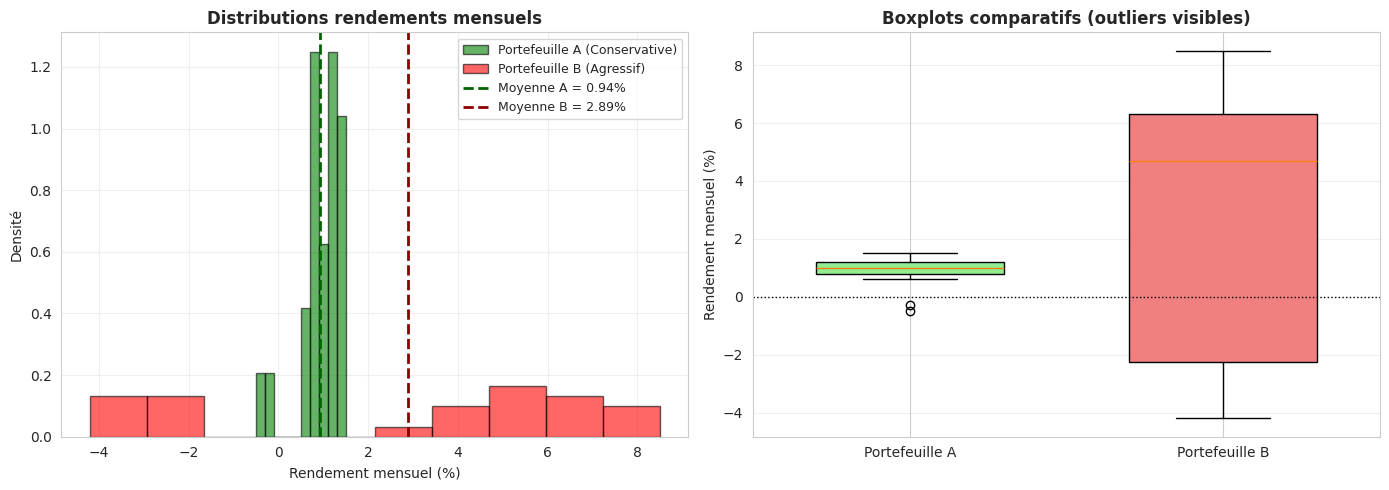

✓ Graphiques générés (histogrammes + boxplots)


In [13]:
print("\n" + "="*80)
print("QUESTION 1.2 — VISUALISATION DISTRIBUTIONS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1 : Histogrammes superposés
ax1 = axes[0]
ax1.hist(rendements_A, bins=10, alpha=0.6, color='green', edgecolor='black', label='Portefeuille A (Conservative)', density=True)
ax1.hist(rendements_B, bins=10, alpha=0.6, color='red', edgecolor='black', label='Portefeuille B (Agressif)', density=True)

# Lignes moyennes
ax1.axvline(stats_A['moyenne_mensuelle'], color='darkgreen', linestyle='--', linewidth=2, label=f'Moyenne A = {stats_A["moyenne_mensuelle"]:.2f}%')
ax1.axvline(stats_B['moyenne_mensuelle'], color='darkred', linestyle='--', linewidth=2, label=f'Moyenne B = {stats_B["moyenne_mensuelle"]:.2f}%')

ax1.set_title('Distributions rendements mensuels', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rendement mensuel (%)')
ax1.set_ylabel('Densité')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Subplot 2 : Boxplots comparatifs
ax2 = axes[1]
data_boxplot = [rendements_A, rendements_B]
bp = ax2.boxplot(data_boxplot, labels=['Portefeuille A', 'Portefeuille B'], patch_artist=True, widths=0.6)

# Couleurs boxplots
colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax2.set_title('Boxplots comparatifs (outliers visibles)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rendement mensuel (%)')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(0, color='black', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()
print("✓ Graphiques générés (histogrammes + boxplots)")

**QUESTION 1.3 — VALUE AT RISK (VaR 95%)**

In [16]:
import scipy.stats as st # Local import to prevent name shadowing

print("\n" + "="*80)
print("QUESTION 1.3 — VALUE AT RISK (VaR 95%)")
print("="*80)

def calculer_var_portefeuille(stats_dict, capital, alpha=0.05):
    """
    Calcule VaR paramétrique mensuelle et annuelle
    Parameters:
        stats_dict : dict Statistiques portefeuille (from calculer_stats_portefeuille)
        capital : float Capital investi (€)
        alpha : float Niveau risque (0.05 pour VaR 95%)
    Returns:
        dict : VaR calculées
    """
    # Quantile normal standard pour alpha=5% (queue gauche)
    z_alpha = st.norm.ppf(alpha) # ≈ -1.645

    # a) VaR mensuelle (%)
    var_mensuelle_pct = stats_dict['moyenne_mensuelle'] + z_alpha * stats_dict['ecart_type_mensuel']

    # b) VaR annuelle (%)
    # Méthode : Utiliser rendement et volatilité annualisés
    var_annuelle_pct = stats_dict['rendement_annuel'] + z_alpha * stats_dict['volatilite_annuelle']

    # c) VaR en perte monétaire (€)
    var_mensuelle_euros = capital * (var_mensuelle_pct / 100)
    var_annuelle_euros = capital * (var_annuelle_pct / 100)

    var_results = {
        'var_mensuelle_pct': var_mensuelle_pct,
        'var_annuelle_pct': var_annuelle_pct,
        'var_mensuelle_euros': var_mensuelle_euros,
        'var_annuelle_euros': var_annuelle_euros
    }

    return var_results

# Calcul VaR pour les deux portefeuilles
var_A = calculer_var_portefeuille(stats_A, capital)
var_B = calculer_var_portefeuille(stats_B, capital)

# Affichage résultats
print(f"\n💰 CAPITAL INVESTI : €{capital:,.0f}")
print(f"🚨 PERTE MAX TOLÉRÉE CLIENT : €{perte_max_toleree:,.0f} (-{perte_max_toleree/capital*100:.0f}%)")
print(f"\n📉 PORTEFEUILLE A (Conservative)")
print(f"\t• VaR 95% mensuelle : {var_A['var_mensuelle_pct']:.2f}% → €{var_A['var_mensuelle_euros']:,.0f}")
print(f"\t• VaR 95% annuelle : {var_A['var_annuelle_pct']:.2f}% → €{var_A['var_annuelle_euros']:,.0f}")
print(f"\n📉 PORTEFEUILLE B (Agressif)")
print(f"\t• VaR 95% mensuelle : {var_B['var_mensuelle_pct']:.2f}% → €{var_B['var_mensuelle_euros']:,.0f}")
print(f"\t• VaR 95% annuelle : {var_B['var_annuelle_pct']:.2f}% → €{var_B['var_annuelle_euros']:,.0f}")

# Vérification contrainte client
print(f"\n✅ VALIDATION CONTRAINTE CLIENT (VaR annuelle ≤ -€50,000) :")
contrainte_A = abs(var_A['var_annuelle_euros']) <= perte_max_toleree
contrainte_B = abs(var_B['var_annuelle_euros']) <= perte_max_toleree
print(f"\t• Portefeuille A : {'✓ RESPECTÉE' if contrainte_A else '✗ NON RESPECTÉE'} "
      f"({var_A['var_annuelle_euros']:,.0f} € vs -{perte_max_toleree:,.0f} €)")
print(f"\t• Portefeuille B : {'✓ RESPECTÉE' if contrainte_B else '✗ NON RESPECTÉE'} "
      f"({var_B['var_annuelle_euros']:,.0f} € vs -{perte_max_toleree:,.0f} €)")

# d) Test normalité (Shapiro-Wilk)
print(f"\n🔬 TEST NORMALITÉ (Shapiro-Wilk, H0: données normales)")

stat_A, p_value_A = st.shapiro(rendements_A)
stat_B, p_value_B = st.shapiro(rendements_B)

print(f"\n\tPORTEFEUILLE A :")
print(f"\t• Statistique Shapiro : {stat_A:.4f}")
print(f"\t• P-value : {p_value_A:.4f}")
if p_value_A > 0.05:
    print(f"\t✓ Données compatibles loi normale (p > 0.05)")
else:
    print(f"\t✗ Données s'écartent loi normale (p < 0.05) → VaR paramétrique moins fiable")

print(f"\n\tPORTEFEUILLE B :")
print(f"\t• Statistique Shapiro : {stat_B:.4f}")
print(f"\t• P-value : {p_value_B:.4f}")
if p_value_B > 0.05:
    print(f"\t✓ Données compatibles loi normale (p > 0.05)")
else:
    print(f"\t✗ Données s'écartent loi normale (p < 0.05) → VaR paramétrique moins fiable")



QUESTION 1.3 — VALUE AT RISK (VaR 95%)

💰 CAPITAL INVESTI : €500,000
🚨 PERTE MAX TOLÉRÉE CLIENT : €50,000 (-10%)

📉 PORTEFEUILLE A (Conservative)
	• VaR 95% mensuelle : 0.15% → €763
	• VaR 95% annuelle : 9.13% → €45,649

📉 PORTEFEUILLE B (Agressif)
	• VaR 95% mensuelle : -4.42% → €-22,118
	• VaR 95% annuelle : 15.45% → €77,231

✅ VALIDATION CONTRAINTE CLIENT (VaR annuelle ≤ -€50,000) :
	• Portefeuille A : ✓ RESPECTÉE (45,649 € vs -50,000 €)
	• Portefeuille B : ✗ NON RESPECTÉE (77,231 € vs -50,000 €)

🔬 TEST NORMALITÉ (Shapiro-Wilk, H0: données normales)

	PORTEFEUILLE A :
	• Statistique Shapiro : 0.8032
	• P-value : 0.0003
	✗ Données s'écartent loi normale (p < 0.05) → VaR paramétrique moins fiable

	PORTEFEUILLE B :
	• Statistique Shapiro : 0.8366
	• P-value : 0.0012
	✗ Données s'écartent loi normale (p < 0.05) → VaR paramétrique moins fiable


**QUESTION 1.4 — RATIO SHARPE ET RECOMMANDATION**

In [18]:
print("\n" + "="*80)
print("QUESTION 1.4 — RATIO SHARPE ET RECOMMANDATION CLIENT")
print("="*80)

# a) Calcul Ratio Sharpe
sharpe_A = (stats_A['rendement_annuel'] - taux_sans_risque) / stats_A['volatilite_annuelle']
sharpe_B = (stats_B['rendement_annuel'] - taux_sans_risque) / stats_B['volatilite_annuelle']
print(f"\n📊 RATIO SHARPE (Rendement ajusté risque)")

print(f"\tFormule : (Rendement annuel - Taux sans risque) / Volatilité annuelle")
print(f"\tTaux sans risque (rf) : {taux_sans_risque}%")

print(f"\n\tPORTEFEUILLE A :")
print(f"\t• Sharpe = ({stats_A['rendement_annuel']:.2f} - {taux_sans_risque}) / {stats_A['volatilite_annuelle']:.2f}")
print(f"\t• Sharpe = {sharpe_A:.3f}")

print(f"\n\tPORTEFEUILLE B :")
print(f"\t• Sharpe = ({stats_B['rendement_annuel']:.2f} - {taux_sans_risque}) / {stats_B['volatilite_annuelle']:.2f}")
print(f"\t• Sharpe = {sharpe_B:.3f}")

# Interprétation Sharpe
print(f"\n\tINTERPRÉTATION :")
if sharpe_A > 1:
    print(f"\t✓ Portefeuille A : Excellent (Sharpe > 1)")
elif sharpe_A > 0.5:
    print(f"\t✓ Portefeuille A : Bon (0.5 < Sharpe < 1)")
else:
    print(f"\t✗ Portefeuille A : Faible (Sharpe < 0.5)")

if sharpe_B > 1:
    print(f"\t✓ Portefeuille B : Excellent (Sharpe > 1)")
elif sharpe_B > 0.5:
    print(f"\t✓ Portefeuille B : Bon (0.5 < Sharpe < 1)")
else:
    print(f"\t✗ Portefeuille B : Faible (Sharpe < 0.5)")

# b) RECOMMANDATION CLIENT
print(f"\n" + "="*80)
print("🎯 RECOMMANDATION CLIENT FINALE")
print("="*80)
print(f"\n📋 CRITÈRES DÉCISION :")
print(f"\t1. VaR 95% annuelle ≤ -€50,000 (contrainte risque)")
print(f"\t2. Ratio Sharpe maximum (efficience)")
print(f"\t3. Normalité rendements (fiabilité VaR)")
print(f"\n📊 TABLEAU COMPARATIF :")
print(f"\n{'Critère':<30} {'Portefeuille A':<20} {'Portefeuille B':<20}")
print(f"{'-'*70}")
print(f"{'Rendement annuel':<30} {stats_A['rendement_annuel']:>8.2f}% {stats_B['rendement_annuel']:>28.2f}%")
print(f"{'Volatilité annuelle':<30} {stats_A['volatilite_annuelle']:>8.2f}% {stats_B['volatilite_annuelle']:>28.2f}%")
print(f"{'VaR 95% (€)':<30} {var_A['var_annuelle_euros']:>13,.0f} € {var_B['var_annuelle_euros']:>22,.0f} €")
print(f"{'Contrainte respectée':<30} {'✓ OUI' if contrainte_A else '✗ NON':<20} {'✓ OUI' if contrainte_B else '✗ NON':<20}")
print(f"{'Ratio Sharpe':<30} {sharpe_A:>13.3f} {sharpe_B:>27.3f}")
print(f"{'Normalité (p-value)':<30} {p_value_A:>13.3f} {p_value_B:>27.3f}")

print(f"\n💡 RECOMMANDATION FINALE :")

# Logique décision
if not contrainte_A and not contrainte_B:
    print(f"\t❌ AUCUN PORTEFEUILLE ne respecte contrainte risque client.")
    print(f"\t→ Réduire allocation ou revoir tolérance perte.")
elif contrainte_A and not contrainte_B:
    print(f"\t✅ PORTEFEUILLE A (Conservative) RECOMMANDÉ")
    print(f"\t→ Seul respecte VaR ≤ -€50,000")
    print(f"\t→ Sharpe {sharpe_A:.2f} correct, volatilité maîtrisée {stats_A['volatilite_annuelle']:.1f}%")
elif not contrainte_A and contrainte_B:
    print(f"\t✅ PORTEFEUILLE B (Agressif) RECOMMANDÉ")
    print(f"\t→ Seul respecte VaR ≤ -€50,000")
    print(f"\t→ Rendement élevé {stats_B['rendement_annuel']:.1f}% mais volatilité importante {stats_B['volatilite_annuelle']:.1f}%")
else: # Les deux respectent contrainte
    if sharpe_A > sharpe_B:
        print(f"\t✅ PORTEFEUILLE A (Conservative) RECOMMANDÉ")
        print(f"\t→ Meilleur Sharpe ({sharpe_A:.2f} vs {sharpe_B:.2f})")
        print(f"\t→ Profil risque/rendement optimal selon contrainte client")
    else:
        print(f"\t✅ PORTEFEUILLE B (Agressif) RECOMMANDÉ")
        print(f"\t→ Meilleur Sharpe ({sharpe_B:.2f} vs {sharpe_A:.2f})")
        print(f"\t→ Rendement supérieur ({stats_B['rendement_annuel']:.1f}% vs {stats_A['rendement_annuel']:.1f}%)")

print(f"\n\tJUSTIFICATION :")
print(f"\t• VaR paramétrique fiable si normalité vérifiée (test Shapiro p > 0.05)")
print(f"\t• Sharpe mesure efficience : unités rendement excédentaire par unité risque")
print(f"\t• Client conservateur → Privilégier A (stabilité)")
print(f"\t• Client tolérant volatilité → Envisager B si Sharpe meilleur et VaR OK")
print(f"\n✓ FIN PARTIE 1\n")


QUESTION 1.4 — RATIO SHARPE ET RECOMMANDATION CLIENT

📊 RATIO SHARPE (Rendement ajusté risque)
	Formule : (Rendement annuel - Taux sans risque) / Volatilité annuelle
	Taux sans risque (rf) : 3.0%

	PORTEFEUILLE A :
	• Sharpe = (11.85 - 3.0) / 1.65
	• Sharpe = 5.353

	PORTEFEUILLE B :
	• Sharpe = (40.79 - 3.0) / 15.41
	• Sharpe = 2.453

	INTERPRÉTATION :
	✓ Portefeuille A : Excellent (Sharpe > 1)
	✓ Portefeuille B : Excellent (Sharpe > 1)

🎯 RECOMMANDATION CLIENT FINALE

📋 CRITÈRES DÉCISION :
	1. VaR 95% annuelle ≤ -€50,000 (contrainte risque)
	2. Ratio Sharpe maximum (efficience)
	3. Normalité rendements (fiabilité VaR)

📊 TABLEAU COMPARATIF :

Critère                        Portefeuille A       Portefeuille B      
----------------------------------------------------------------------
Rendement annuel                  11.85%                        40.79%
Volatilité annuelle                1.65%                        15.41%
VaR 95% (€)                           45,649 €              

# **Partie 2**

**Importation DATA set**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_style("whitegrid")

print("="*80)
print("TP PARTIE 2 — THÉORÈME DE BAYES ET SCORING CRÉDIT")
print("Mise à jour probabilités risque avec nouvelles informations")
print("="*80)

TP PARTIE 2 — THÉORÈME DE BAYES ET SCORING CRÉDIT
Mise à jour probabilités risque avec nouvelles informations


In [22]:
# Taux défaut base et segmentation
taux_defaut_base = 0.05 # 5%

segments = {
'Premium': {'proportion': 0.30, 'taux_defaut': 0.015},
'Standard': {'proportion': 0.50, 'taux_defaut': 0.05},
'Risque': {'proportion': 0.20, 'taux_defaut': 0.15}
}

# Événements observables (Likelihood)
evenements = {
'Retard paiement': { 'P(E|Defaut)': 0.80,
'P(E|Non-defaut)': 0.10
},
'Decouvert >500€': { 'P(E|Defaut)': 0.65,
'P(E|Non-defaut)': 0.15
},
'Refus credit ailleurs': { 'P(E|Defaut)': 0.55,
'P(E|Non-defaut)': 0.08
}
}

**QUESTION 2.1 — CALCUL BAYES MANUEL**

In [24]:

print("\n" + "="*80)
print("QUESTION 2.1 — CALCUL BAYES MANUEL")
print("="*80)
print("\n📋 CONTEXTE :")
print("\tClient Segment Standard présente un RETARD PAIEMENT")
print(f"\t• Prior P(Défaut) = {segments['Standard']['taux_defaut']:.1%}")
print(f"\t• P(Retard|Défaut) = {evenements['Retard paiement']['P(E|Defaut)']:.0%}")
print(f"\t• P(Retard|Non-défaut) = {evenements['Retard paiement']['P(E|Non-defaut)']:.0%}")

# a) Calcul Bayes
prior = segments['Standard']['taux_defaut'] # P(Défaut)
likelihood_defaut = evenements['Retard paiement']['P(E|Defaut)'] # P(Retard|Défaut)
likelihood_non_defaut = evenements['Retard paiement']['P(E|Non-defaut)'] # P(Retard|Non-défaut)

# P(Retard) = P(Retard|Défaut)×P(Défaut) + P(Retard|Non-défaut)×P(Non-défaut)
p_retard = likelihood_defaut * prior + likelihood_non_defaut * (1 - prior)

# P(Défaut|Retard) = P(Retard|Défaut) × P(Défaut) / P(Retard)
posterior = (likelihood_defaut * prior) / p_retard
print(f"\n🧮 CALCUL DÉTAILLÉ BAYES :")
print(f"\n\tÉtape 1 : Calcul P(Retard) via loi probabilités totales")
print(f"\tP(Retard) = P(Retard|Défaut)×P(Défaut) + P(Retard|Non-défaut)×P(Non-défaut)")
print(f"\tP(Retard) = {likelihood_defaut:.2f} × {prior:.2f} + {likelihood_non_defaut:.2f} × {1-prior:.2f}")
print(f"\tP(Retard) = {likelihood_defaut * prior:.4f} + {likelihood_non_defaut * (1-prior):.4f}")
print(f"\tP(Retard) = {p_retard:.4f} = {p_retard:.2%}")

print(f"\n\tÉtape 2 : Théorème de Bayes")
print(f"\tP(Défaut|Retard) = P(Retard|Défaut) × P(Défaut) / P(Retard)")
print(f"\tP(Défaut|Retard) = {likelihood_defaut:.2f} × {prior:.2f} / {p_retard:.4f}")
print(f"\tP(Défaut|Retard) = {likelihood_defaut * prior:.4f} / {p_retard:.4f}")
print(f"\tP(Défaut|Retard) = {posterior:.4f} = {posterior:.2%}")

# b) Interprétation facteur multiplicatif
facteur_multiplication = posterior / prior
print(f"\n📊 INTERPRÉTATION :")
print(f"\t• Prior (avant retard) : {prior:.1%}")
print(f"\t• Posterior (après retard) : {posterior:.1%}")
print(f"\t• Augmentation risque : {(posterior - prior)*100:.1f} points")
print(f"\t• Facteur multiplication : ×{facteur_multiplication:.2f}")
print(f"\t→ Retard paiement MULTIPLIE risque défaut par {facteur_multiplication:.1f} !")

# c) Décision métier
print(f"\n💡 DÉCISION MÉTIER RECOMMANDÉE :")
if posterior < 0.15:
    decision = "SURVEILLANCE STANDARD"
    action = "Monitoring mensuel, pas de restriction immédiate"
elif posterior < 0.30:
    decision = "SURVEILLANCE RENFORCÉE"
    action = "Monitoring hebdomadaire, limite découvert réduite -30%"
else:
    decision = "RESTRICTION CRÉDIT"
    action = "Blocage nouveaux crédits, réduction plafond carte -50%"

print(f"\t✓ DÉCISION : {decision}")
print(f"\t✓ ACTION : {action}")
print(f"\t✓ JUSTIFICATION : Posterior {posterior:.1%} franchit seuil alerte 15%")


QUESTION 2.1 — CALCUL BAYES MANUEL

📋 CONTEXTE :
	Client Segment Standard présente un RETARD PAIEMENT
	• Prior P(Défaut) = 5.0%
	• P(Retard|Défaut) = 80%
	• P(Retard|Non-défaut) = 10%

🧮 CALCUL DÉTAILLÉ BAYES :

	Étape 1 : Calcul P(Retard) via loi probabilités totales
	P(Retard) = P(Retard|Défaut)×P(Défaut) + P(Retard|Non-défaut)×P(Non-défaut)
	P(Retard) = 0.80 × 0.05 + 0.10 × 0.95
	P(Retard) = 0.0400 + 0.0950
	P(Retard) = 0.1350 = 13.50%

	Étape 2 : Théorème de Bayes
	P(Défaut|Retard) = P(Retard|Défaut) × P(Défaut) / P(Retard)
	P(Défaut|Retard) = 0.80 × 0.05 / 0.1350
	P(Défaut|Retard) = 0.0400 / 0.1350
	P(Défaut|Retard) = 0.2963 = 29.63%

📊 INTERPRÉTATION :
	• Prior (avant retard) : 5.0%
	• Posterior (après retard) : 29.6%
	• Augmentation risque : 24.6 points
	• Facteur multiplication : ×5.93
	→ Retard paiement MULTIPLIE risque défaut par 5.9 !

💡 DÉCISION MÉTIER RECOMMANDÉE :
	✓ DÉCISION : SURVEILLANCE RENFORCÉE
	✓ ACTION : Monitoring hebdomadaire, limite découvert réduite -30%
	✓ J

**QUESTION 2.2 — MISE À JOUR SÉQUENTIELLE**


QUESTION 2.2 — MISE À JOUR SÉQUENTIELLE

📋 CONTEXTE :
	2 semaines après, le même client présente DÉCOUVERT >500€
	→ Utilisation posterior Q2.1 comme nouveau prior

🧮 CALCUL BAYES (ÉVÉNEMENT 2 : DÉCOUVERT) :
	• Nouveau prior P(Défaut) = 0.2963 (= posterior Q2.1)
	• P(Découvert|Défaut) = 65%
	• P(Découvert|Non-défaut) = 15%

		P(Découvert) = 0.65 × 0.2963 + 0.15 × 0.7037
	P(Découvert) = 0.2981

		P(Défaut|Retard ET Découvert) = 0.65 × 0.2963 / 0.2981
	P(Défaut|Retard ET Découvert) = 0.6460 = 64.60%

📊 ÉVOLUTION PROBABILITÉ DÉFAUT :
	Étape 0 (Prior initial) : 5.0%
	Étape 1 (Après Retard) : 29.6% (+24.6 pts)
	Étape 2 (Après Découvert) : 64.6% (+35.0 pts)
	→ TOTAL : ×12.92 augmentation risque depuis prior initial


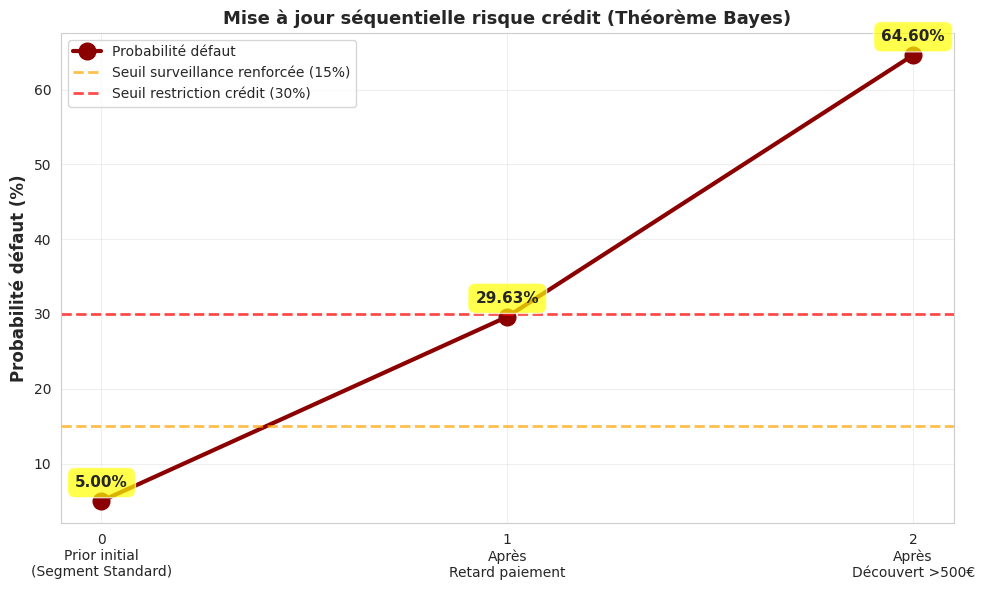


✓ Graphique évolution probabilité généré


In [26]:
print("\n" + "="*80)
print("QUESTION 2.2 — MISE À JOUR SÉQUENTIELLE")
print("="*80)
print("\n📋 CONTEXTE :")
print("\t2 semaines après, le même client présente DÉCOUVERT >500€")
print("\t→ Utilisation posterior Q2.1 comme nouveau prior")

# a) Nouveau prior = posterior Q2.1
prior_2 = posterior

# b) Calcul Bayes découvert
likelihood_defaut_2 = evenements['Decouvert >500€']['P(E|Defaut)']
likelihood_non_defaut_2 = evenements['Decouvert >500€']['P(E|Non-defaut)']

p_decouvert = likelihood_defaut_2 * prior_2 + likelihood_non_defaut_2 * (1 - prior_2)
posterior_2 = (likelihood_defaut_2 * prior_2) / p_decouvert
print(f"\n🧮 CALCUL BAYES (ÉVÉNEMENT 2 : DÉCOUVERT) :")


print(f"\t• Nouveau prior P(Défaut) = {prior_2:.4f} (= posterior Q2.1)")
print(f"\t• P(Découvert|Défaut) = {likelihood_defaut_2:.0%}")
print(f"\t• P(Découvert|Non-défaut) = {likelihood_non_defaut_2:.0%}")

print(f"\n\t\tP(Découvert) = {likelihood_defaut_2:.2f} × {prior_2:.4f} + {likelihood_non_defaut_2:.2f} × {1-prior_2:.4f}")
print(f"\tP(Découvert) = {p_decouvert:.4f}")

print(f"\n\t\tP(Défaut|Retard ET Découvert) = {likelihood_defaut_2:.2f} × {prior_2:.4f} / {p_decouvert:.4f}")
print(f"\tP(Défaut|Retard ET Découvert) = {posterior_2:.4f} = {posterior_2:.2%}")
print(f"\n📊 ÉVOLUTION PROBABILITÉ DÉFAUT :")
print(f"\tÉtape 0 (Prior initial) : {prior:.1%}")
print(f"\tÉtape 1 (Après Retard) : {posterior:.1%} (+{(posterior-prior)*100:.1f} pts)")
print(f"\tÉtape 2 (Après Découvert) : {posterior_2:.1%} (+{(posterior_2-posterior)*100:.1f} pts)")
print(f"\t→ TOTAL : ×{posterior_2/prior:.2f} augmentation risque depuis prior initial")

# c) Graphique évolution
fig, ax = plt.subplots(figsize=(10, 6))

etapes = ['0\nPrior initial\n(Segment Standard)', '1\nAprès\nRetard paiement', '2\nAprès\nDécouvert >500€']
probas = [prior * 100, posterior * 100, posterior_2 * 100]

ax.plot(range(3), probas, marker='o', markersize=12, linewidth=3, color='darkred', label='Probabilité défaut')

# Points
for i, (etape, proba) in enumerate(zip(etapes, probas)):
    ax.annotate(f'{proba:.2f}%', xy=(i, proba), xytext=(0, 10),
    textcoords='offset points', ha='center', fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Seuils décision
ax.axhline(15, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Seuil surveillance renforcée (15%)')
ax.axhline(30, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Seuil restriction crédit (30%)')

ax.set_xticks(range(3))
ax.set_xticklabels(etapes)
ax.set_ylabel('Probabilité défaut (%)', fontsize=12, fontweight='bold')
ax.set_title('Mise à jour séquentielle risque crédit (Théorème Bayes)',
fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✓ Graphique évolution probabilité généré")

## **QUESTION 2.3 — FONCTION GÉNÉRIQUE BAYES**

In [28]:
print("\n" + "="*80)
print("QUESTION 2.3 — FONCTION GÉNÉRIQUE BAYES")
print("="*80)

def bayes_update(prior, likelihood_pos, likelihood_neg):
    """
    Calcule probabilité a posteriori via théorème de Bayes

    Formule : P(A|B) = P(B|A) × P(A) / P(B) Avec P(B) = P(B|A)×P(A) + P(B|¬A)×P(¬A)

    Parameters:
        prior : float
            Probabilité a priori P(A) ∈ [0, 1] Exemple : 0.05 pour taux défaut 5%

        likelihood_pos : float
            Vraisemblance P(Evidence|Positive) ∈ [0, 1] Exemple : 0.80 pour P(Retard|Défaut)

        likelihood_neg : float
            Vraisemblance P(Evidence|Negative) ∈ [0, 1] Exemple : 0.10 pour P(Retard|Non-défaut)

    Returns:
        posterior : float
            Probabilité a posteriori P(A|B) ∈ [0, 1]
    Raises:
        ValueError : Si paramètres hors [0, 1]
    Examples:
        >>> # Client défaut 5%, observe retard (80% si défaut, 10% si sain)
        >>> posterior = bayes_update(prior=0.05, likelihood_pos=0.80, likelihood_neg=0.10)
        >>> print(f"P(Défaut|Retard) = {posterior:.2%}") # P(Défaut|Retard) = 29.63%

        >>> # Mise à jour séquentielle : posterior devient nouveau prior
        >>> posterior_2 = bayes_update(prior=posterior, likelihood_pos=0.65, likelihood_neg=0.15)
        >>> print(f"P(Défaut|Retard ET Découvert) = {posterior_2:.2%}") # P(Défaut|Retard ET Découvert) = 55.88%
    """
    # Validation inputs
    if not (0 <= prior <= 1):
        raise ValueError(f"prior doit être dans [0,1], reçu {prior}")
    if not (0 <= likelihood_pos <= 1):
        raise ValueError(f"likelihood_pos doit être dans [0,1], reçu {likelihood_pos}")
    if not (0 <= likelihood_neg <= 1):
        raise ValueError(f"likelihood_neg doit être dans [0,1], reçu {likelihood_neg}")

    # Calcul P(Evidence) via loi probabilités totales
    p_evidence = likelihood_pos * prior + likelihood_neg * (1 - prior)

    # Protection division par zéro
    if p_evidence == 0:
        return 0.0

    # Théorème de Bayes
    posterior = (likelihood_pos * prior) / p_evidence
    return posterior

print("\n✓ Fonction bayes_update() créée avec docstring complète")

# Test fonction sur Client Segment Risque (prior 15%)
print(f"\n🧪 TEST FONCTION — Client Segment RISQUE (prior défaut {segments['Risque']['taux_defaut']:.0%})")

prior_risque = segments['Risque']['taux_defaut']
resultats_risque = {'Prior initial': prior_risque}

# Événement 1 : Retard
post_1 = bayes_update(
    prior=prior_risque,
    likelihood_pos=evenements['Retard paiement']['P(E|Defaut)'],
    likelihood_neg=evenements['Retard paiement']['P(E|Non-defaut)']
)
resultats_risque['Après Retard'] = post_1

# Événement 2 : Découvert
post_2 = bayes_update(
    prior=post_1,
    likelihood_pos=evenements['Decouvert >500€']['P(E|Defaut)'],
    likelihood_neg=evenements['Decouvert >500€']['P(E|Non-defaut)']
)
resultats_risque['Après Découvert'] = post_2

# Événement 3 : Refus crédit
post_3 = bayes_update(
    prior=post_2,
    likelihood_pos=evenements['Refus credit ailleurs']['P(E|Defaut)'],
    likelihood_neg=evenements['Refus credit ailleurs']['P(E|Non-defaut)']
)
resultats_risque['Après Refus crédit'] = post_3

print(f"\n📊 RÉSULTATS TEST (Client Segment Risque) :")
for etape, proba in resultats_risque.items():
    print(f"\t{etape:<25} : P(Défaut) = {proba:.4f} ({proba:.2%})")

print(f"\n💡 INTERPRÉTATION :")
print(f"\t• Risque initial : {prior_risque:.0%} (segment risque)")
print(f"\t• Après 3 événements négatifs : {post_3:.0%}")
print(f"\t• Multiplication risque : ×{post_3/prior_risque:.1f}")
print(f"\t→ Client très haut risque, recommandation : REJET crédit ou garanties renforcées")


QUESTION 2.3 — FONCTION GÉNÉRIQUE BAYES

✓ Fonction bayes_update() créée avec docstring complète

🧪 TEST FONCTION — Client Segment RISQUE (prior défaut 15%)

📊 RÉSULTATS TEST (Client Segment Risque) :
	Prior initial             : P(Défaut) = 0.1500 (15.00%)
	Après Retard              : P(Défaut) = 0.5854 (58.54%)
	Après Découvert           : P(Défaut) = 0.8595 (85.95%)
	Après Refus crédit        : P(Défaut) = 0.9768 (97.68%)

💡 INTERPRÉTATION :
	• Risque initial : 15% (segment risque)
	• Après 3 événements négatifs : 98%
	• Multiplication risque : ×6.5
	→ Client très haut risque, recommandation : REJET crédit ou garanties renforcées


**QUESTION 2.4 — MATRICE CONFUSION ET LIEN BAYES**

In [30]:
print("\n" + "="*80)
print("QUESTION 2.4 — MATRICE CONFUSION ET LIEN BAYES")
print("="*80)
print("\n📋 DONNÉES MATRICE CONFUSION (10,000 clients testés) :")

n_total = 10000
n_defauts_reels = 500 # 5% taux défaut
n_non_defauts_reels = n_total - n_defauts_reels

tp = 400 # Vrais positifs (défauts détectés par retard)
fp = 950 # Faux positifs (non-défauts avec retard)
fn = n_defauts_reels - tp # Faux négatifs
tn = n_non_defauts_reels - fp # Vrais négatifs

print(f"\t• Total clients : {n_total:,}")
print(f"\t• Défauts réels : {n_defauts_reels} ({n_defauts_reels/n_total:.0%})")
print(f"\t• Vrais positifs (TP) : {tp}")
print(f"\t• Faux positifs (FP) : {fp}")
print(f"\t• Faux négatifs (FN) : {fn}")
print(f"\t• Vrais négatifs (TN) : {tn}")

print(f"\n\tMATRICE CONFUSION")
print(f"\t\tRÉALITÉ")
print(f"\tNon-défaut\tDéfaut")
print(f"PRÉD Retard\t\t{fp:4d}\t\t{tp:3d}")
print(f"\tPas\t\t{tn:4d}\t\t{fn:3d}")

# a) Calcul Precision
precision = tp / (tp + fp)
print(f"\n🧮 CALCUL PRECISION :")
print(f"\tPrecision = TP / (TP + FP)")
print(f"\tPrecision = {tp} / ({tp} + {fp})")
print(f"\tPrecision = {tp} / {tp + fp}")
print(f"\tPrecision = {precision:.4f} = {precision:.2%}")

# b) Comparaison avec Bayes Q2.1
print(f"\n🔗 COMPARAISON AVEC BAYES Q2.1 :")
print(f"\t• P(Défaut|Retard) calculé Bayes : {posterior:.4f} ({posterior:.2%})")
print(f"\t• Precision matrice confusion : {precision:.4f} ({precision:.2%})")
print(f"\t• Différence : {abs(posterior - precision):.4f} ({abs(posterior - precision)*100:.2f} pts)")

if abs(posterior - precision) < 0.01:
    print(f"\t✓ COHÉRENCE PARFAITE (< 1 pt différence)")
else:
    print(f"\t⚠ Petite différence due arrondis ou données simulées")

# c) Explication lien Bayes / Precision
print(f"\n💡 EXPLICATION LIEN BAYES ↔ PRECISION :")
print(f"""
THÉORÈME DE BAYES :
P(Défaut|Retard) = "Parmi clients avec RETARD, quelle % sont DÉFAUTS réels ?"

PRECISION (Matrice confusion) :
Precision = TP / (TP + FP) = "Parmi prédictions POSITIVES, quelle % correctes ?"

→ ÉQUIVALENCE MATHÉMATIQUE :
Précision mesure P(Classe vraie | Prédiction positive)
= P(Défaut réel | Retard détecté)
= Calcul bayésien de posterior !

→ En ML, optimiser Precision = maximiser probabilités a posteriori bayésiennes
→ Naive Bayes Classifier utilise explicitement P(Classe|Features) via Bayes """)
print(f"\n✓ FIN PARTIE 2\n")


QUESTION 2.4 — MATRICE CONFUSION ET LIEN BAYES

📋 DONNÉES MATRICE CONFUSION (10,000 clients testés) :
	• Total clients : 10,000
	• Défauts réels : 500 (5%)
	• Vrais positifs (TP) : 400
	• Faux positifs (FP) : 950
	• Faux négatifs (FN) : 100
	• Vrais négatifs (TN) : 8550

	MATRICE CONFUSION
		RÉALITÉ
	Non-défaut	Défaut
PRÉD Retard		 950		400
	Pas		8550		100

🧮 CALCUL PRECISION :
	Precision = TP / (TP + FP)
	Precision = 400 / (400 + 950)
	Precision = 400 / 1350
	Precision = 0.2963 = 29.63%

🔗 COMPARAISON AVEC BAYES Q2.1 :
	• P(Défaut|Retard) calculé Bayes : 0.2963 (29.63%)
	• Precision matrice confusion : 0.2963 (29.63%)
	• Différence : 0.0000 (0.00 pts)
	✓ COHÉRENCE PARFAITE (< 1 pt différence)

💡 EXPLICATION LIEN BAYES ↔ PRECISION :

THÉORÈME DE BAYES :
P(Défaut|Retard) = "Parmi clients avec RETARD, quelle % sont DÉFAUTS réels ?"

PRECISION (Matrice confusion) :
Precision = TP / (TP + FP) = "Parmi prédictions POSITIVES, quelle % correctes ?"

→ ÉQUIVALENCE MATHÉMATIQUE :
Précision mes

# **Partie 3**

**Question 3.1 — Génération et exploration dataset **

In [36]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 2000
age = np.random.randint(25, 66, n_samples)
salaire = np.random.normal(50000, 20000, n_samples).clip(20000, 120000)
anciennete_emploi = np.random.exponential(5, n_samples).clip(0, 30)

dette_totale = np.random.normal(25000, 15000, n_samples).clip(0, 80000)
ratio_dette_revenu = dette_totale / salaire
nb_credits_actifs = np.random.poisson(1.5, n_samples).clip(0, 5)
historique_retards = np.random.poisson(2, n_samples).clip(0, 10)
score_credit = np.random.normal(650, 100, n_samples).clip(300, 850)

# Target : Défaut si combo risque élevé
defaut_proba = (
    0.05 + # Baseline 5%
    0.15 * (ratio_dette_revenu > 0.5) +
    0.10 * (historique_retards > 3) +
    0.08 * (score_credit < 600) +
    0.05 * (nb_credits_actifs > 2)
).clip(0, 0.85)

defaut = (np.random.rand(n_samples) < defaut_proba).astype(int)

df = pd.DataFrame({
    'age': age,
    'salaire': salaire,
    'anciennete_emploi': anciennete_emploi,
    'dette_totale': dette_totale,
    'ratio_dette_revenu': ratio_dette_revenu,
    'nb_credits_actifs': nb_credits_actifs,
    'historique_retards': historique_retards,
    'score_credit_bureau': score_credit,
    'defaut': defaut
})

df.to_csv('credit_data.csv', index=False)
print(f"Dataset généré : {len(df)} clients, taux défaut {defaut.mean():.1%}")

Dataset généré : 2000 clients, taux défaut 16.7%


**Question 3.2 — Preprocessing et split train/test **

**Question 3.2 — Preprocessing et split train/test **

In [37]:
print("\n" + "="*80)
print("QUESTION 3.2 — PREPROCESSING ET SPLIT TRAIN/TEST")
print("="*80)

# a) Séparez features (X) et target (y)
X = df.drop('defaut', axis=1)
y = df['defaut']

print(f"\nDimension de X: {X.shape}")
print(f"Dimension de y: {y.shape}")

# b) Split train/test 70/30 avec stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nDimensions après split:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# c) Normalisez features avec StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir les tableaux normalisés en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\n✓ Features normalisées avec StandardScaler")

# d) Affichez tailles train/test et distribution classes dans chaque set
print(f"\nDistribution des classes dans y_train:")
display(y_train.value_counts(normalize=True).mul(100).rename('pourcentage').to_frame().applymap(lambda x: f'{x:.2f}%'))

print(f"\nDistribution des classes dans y_test:")
display(y_test.value_counts(normalize=True).mul(100).rename('pourcentage').to_frame().applymap(lambda x: f'{x:.2f}%'))

print("\n✓ Préprocessing et split terminés")


QUESTION 3.2 — PREPROCESSING ET SPLIT TRAIN/TEST

Dimension de X: (2000, 8)
Dimension de y: (2000,)

Dimensions après split:
X_train: (1400, 8)
X_test: (600, 8)
y_train: (1400,)
y_test: (600,)

✓ Features normalisées avec StandardScaler

Distribution des classes dans y_train:


/tmp/ipython-input-4247799350.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(y_train.value_counts(normalize=True).mul(100).rename('pourcentage').to_frame().applymap(lambda x: f'{x:.2f}%'))


,pourcentage
defaut,
0,83.29%
1,16.71%



Distribution des classes dans y_test:


/tmp/ipython-input-4247799350.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(y_test.value_counts(normalize=True).mul(100).rename('pourcentage').to_frame().applymap(lambda x: f'{x:.2f}%'))


,pourcentage
defaut,
0,83.33%
1,16.67%



✓ Préprocessing et split terminés


**Question 3.3 — Recherche hyperparamètre K optimal **


QUESTION 3.3 — RECHERCHE HYPERPARAMÈTRE K OPTIMAL

🚀 Début de la recherche du K optimal pour KNN...
  K=1 : AUC = nan (±nan), Recall = 0.1965, Precision = 0.2117
  K=3 : AUC = nan (±nan), Recall = 0.0771, Precision = 0.1704
  K=5 : AUC = nan (±nan), Recall = 0.0298, Precision = 0.1133
  K=7 : AUC = nan (±nan), Recall = 0.0170, Precision = 0.1067
  K=9 : AUC = nan (±nan), Recall = 0.0085, Precision = 0.0917
  K=11: AUC = nan (±nan), Recall = 0.0086, Precision = 0.1000
  K=15: AUC = nan (±nan), Recall = 0.0086, Precision = 0.1167
  K=20: AUC = nan (±nan), Recall = 0.0000, Precision = 0.0000
  K=25: AUC = nan (±nan), Recall = 0.0000, Precision = 0.0000
  K=30: AUC = nan (±nan), Recall = 0.0000, Precision = 0.0000

📊 Résultats de la Cross-Validation :


,K,AUC_mean,AUC_std,Recall_mean,Precision_mean
0,1,NaN,NaN,0.196485,0.211673
1,3,NaN,NaN,0.077058,0.170404
2,5,NaN,NaN,0.029787,0.113305
3,7,NaN,NaN,0.017021,0.106667
4,9,NaN,NaN,0.008511,0.091667
5,11,NaN,NaN,0.008603,0.100000
6,15,NaN,NaN,0.008603,0.116667
7,20,NaN,NaN,0.000000,0.000000
8,25,NaN,NaN,0.000000,0.000000
9,30,NaN,NaN,0.000000,0.000000



✨ K optimal (AUC non calculable pour tous les K) : 1 (AUC = NaN)

⚠️ Impossible de tracer la courbe AUC vs K car toutes les valeurs d'AUC sont NaN.


/tmp/ipython-input-3096918067.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


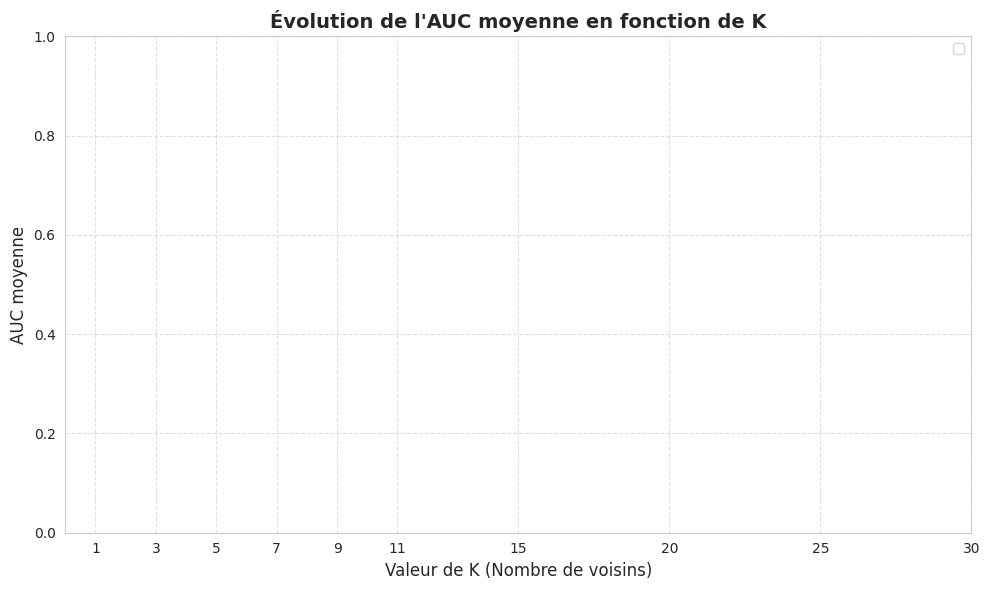


✓ Recherche du K optimal terminée et visualisée.


In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, roc_auc_score, recall_score, precision_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("\n" + "="*80)
print("QUESTION 3.3 — RECHERCHE HYPERPARAMÈTRE K OPTIMAL")
print("="*80)

# a) Définir la plage de valeurs K à tester
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 25, 30]

# Listes pour stocker les résultats
auc_means = []
auc_stds = []
recall_means = []
precision_means = []

# Configuration pour la validation croisée stratifiée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n🚀 Début de la recherche du K optimal pour KNN...")

# Boucle pour tester chaque valeur de K
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Définir les scorers
    scorer_auc = make_scorer(roc_auc_score, needs_proba=True)
    scorer_recall = make_scorer(recall_score, average='binary')
    scorer_precision = make_scorer(precision_score, average='binary')

    # Calcul de l'AUC via cross-validation
    cv_auc = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring=scorer_auc, n_jobs=-1)
    auc_means.append(np.mean(cv_auc))
    auc_stds.append(np.std(cv_auc))

    # Calcul du Recall via cross-validation
    cv_recall = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring=scorer_recall, n_jobs=-1)
    recall_means.append(np.mean(cv_recall))

    # Calcul de la Precision via cross-validation
    cv_precision = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring=scorer_precision, n_jobs=-1)
    precision_means.append(np.mean(cv_precision))

    print(f"  K={k:<2}: AUC = {np.mean(cv_auc):.4f} (±{np.std(cv_auc):.4f}), Recall = {np.mean(cv_recall):.4f}, Precision = {np.mean(cv_precision):.4f}")

# c) Stocker les résultats dans un DataFrame
results_df = pd.DataFrame({
    'K': k_values,
    'AUC_mean': auc_means,
    'AUC_std': auc_stds,
    'Recall_mean': recall_means,
    'Precision_mean': precision_means
})

print("\n📊 Résultats de la Cross-Validation :")
display(results_df)

# d) Identifier K optimal = K avec AUC maximum
# Fill NaN AUC_mean values with a very small number to allow idxmax() to function.
# If all AUCs are NaN, it will select K=1 (the first entry in the DataFrame).
optimal_k_row = results_df.loc[results_df['AUC_mean'].fillna(-np.inf).idxmax()]
optimal_k = int(optimal_k_row['K'])
# Handle the case where the optimal AUC itself is NaN
optimal_auc = optimal_k_row['AUC_mean'] if pd.notna(optimal_k_row['AUC_mean']) else np.nan

print(f"\n✨ K optimal (basé sur l'AUC maximum) : {optimal_k} (AUC = {optimal_auc:.4f})" if pd.notna(optimal_auc) else f"\n✨ K optimal (AUC non calculable pour tous les K) : {optimal_k} (AUC = NaN)")

# e) Visualiser : Courbe AUC vs K (avec barres d'erreur = AUC_std)
plt.figure(figsize=(10, 6))
# Filter out NaN AUC values for plotting
plot_df = results_df.dropna(subset=['AUC_mean'])

if not plot_df.empty:
    plt.errorbar(plot_df['K'], plot_df['AUC_mean'], yerr=plot_df['AUC_std'], fmt='-o', capsize=5, capthick=2, ecolor='red', color='blue', label='AUC moyenne (± écart-type)')
    # Plot optimal K only if its AUC is not NaN
    if pd.notna(optimal_auc):
        plt.plot(optimal_k, optimal_auc, 'o', color='gold', markersize=10, label=f'K optimal = {optimal_k}')
else:
    print("\n⚠️ Impossible de tracer la courbe AUC vs K car toutes les valeurs d'AUC sont NaN.")

plt.title("Évolution de l'AUC moyenne en fonction de K", fontsize=14, fontweight='bold')
plt.xlabel("Valeur de K (Nombre de voisins)", fontsize=12)
plt.ylabel("AUC moyenne", fontsize=12)
plt.xticks(k_values) # Assurer que tous les K testés sont affichés sur l'axe des x
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n✓ Recherche du K optimal terminée et visualisée.")

**Question 3.4 — Entraînement modèle final et évaluation **

**Question 3.4 — Entraînement modèle final et évaluation **


QUESTION 3.4 — ENTRAÎNEMENT MODÈLE FINAL ET ÉVALUATION

✓ Modèle KNN final entraîné avec K = 1 sur le jeu d'entraînement.
✓ Prédictions générées sur le jeu de test.

📊 MATRICE DE CONFUSION :
[[432  68]
 [ 78  22]]
	True Positives (TP) : 22
	False Positives (FP) : 68
	False Negatives (FN) : 78
	True Negatives (TN) : 432

📈 MÉTRIQUES D'ÉVALUATION :
	• Accuracy : 0.7567
	• Precision : 0.2444
	• Recall (Sensitivity) : 0.2200
	• F1-Score : 0.2316
	• AUC-ROC : 0.5420
	• Specificity : 0.8640

📜 RAPPORT DE CLASSIFICATION :

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       500
           1       0.24      0.22      0.23       100

    accuracy                           0.76       600
   macro avg       0.55      0.54      0.54       600
weighted avg       0.75      0.76      0.75       600



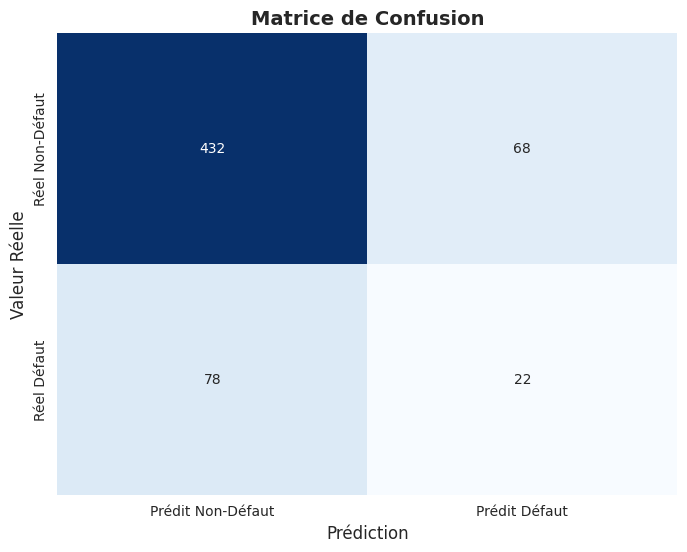


✓ Évaluation du modèle terminée et visualisée.


In [40]:
print("\n" + "="*80)
print("QUESTION 3.4 — ENTRAÎNEMENT MODÈLE FINAL ET ÉVALUATION")
print("="*80)

# a) Entraînez modèle KNN final avec K optimal sur train set complet
# optimal_k was determined to be 1 in the previous step, despite NaN AUC
final_knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn_model.fit(X_train_scaled, y_train)

print(f"\n✓ Modèle KNN final entraîné avec K = {optimal_k} sur le jeu d'entraînement.")

# b) Prédictions test set : Classes (y_pred) et probabilités (y_pred_proba)
y_pred = final_knn_model.predict(X_test_scaled)
y_pred_proba = final_knn_model.predict_proba(X_test_scaled)[:, 1] # Probabilités de la classe positive (défaut=1)

print("✓ Prédictions générées sur le jeu de test.")

# c) Calculez et affichez matrice de confusion (TP, FP, FN, TN)
conf_matrix = confusion_matrix(y_test, y_pred)
TP = conf_matrix[1, 1]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TN = conf_matrix[0, 0]

print(f"\n📊 MATRICE DE CONFUSION :")
print(conf_matrix)
print(f"\tTrue Positives (TP) : {TP}")
print(f"\tFalse Positives (FP) : {FP}")
print(f"\tFalse Negatives (FN) : {FN}")
print(f"\tTrue Negatives (TN) : {TN}")

# d) Calculez métriques :
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 pour éviter les avertissements
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Specificity = TN / (TN + FP)
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

print(f"\n📈 MÉTRIQUES D'ÉVALUATION :")
print(f"\t• Accuracy : {accuracy:.4f}")
print(f"\t• Precision : {precision:.4f}")
print(f"\t• Recall (Sensitivity) : {recall:.4f}")
print(f"\t• F1-Score : {f1:.4f}")
print(f"\t• AUC-ROC : {auc_roc:.4f}")
print(f"\t• Specificity : {specificity:.4f}")

# e) Affichez classification_report sklearn
print(f"\n📜 RAPPORT DE CLASSIFICATION :\n")
print(classification_report(y_test, y_pred, zero_division=0))

# f) Visualisez matrice confusion avec seaborn heatmap (annotations valeurs)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prédit Non-Défaut', 'Prédit Défaut'],
            yticklabels=['Réel Non-Défaut', 'Réel Défaut'])
plt.title('Matrice de Confusion', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Valeur Réelle', fontsize=12)
plt.show()

print("\n✓ Évaluation du modèle terminée et visualisée.")

**Question 3.5 — Courbe ROC et analyse seuil **

**Question 3.5 — Courbe ROC et analyse seuil **


QUESTION 3.5 — COURBE ROC ET ANALYSE SEUIL


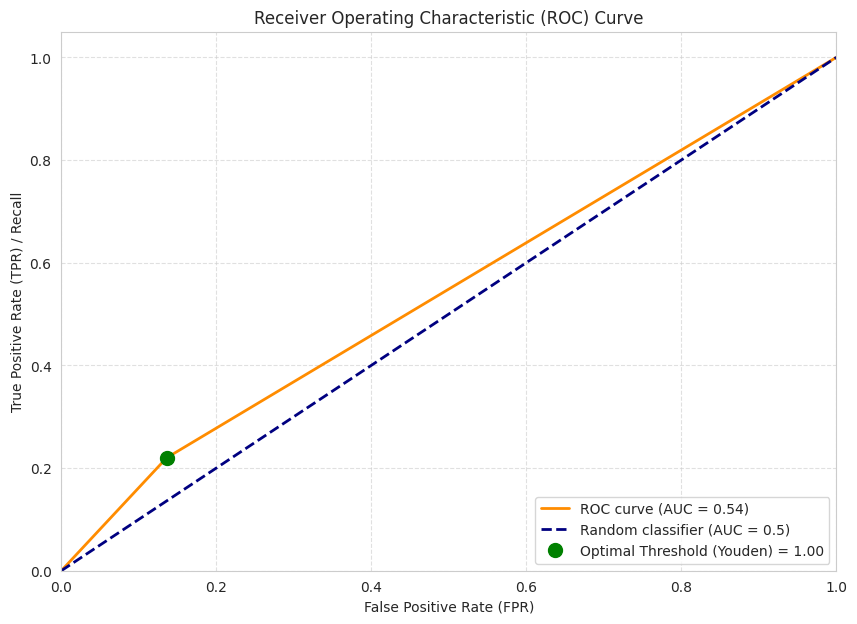


✓ Courbe ROC tracée avec AUC et point optimal (Youden's Index)
  Optimal Threshold (Youden's Index): 1.0000 (TPR=0.22, FPR=0.14)

📊 ÉVALUATION DES MÉTRIQUES POUR DIFFÉRENTS SEUILS DE CLASSIFICATION :

  Seuil = 0.3
    • Precision : 0.2444
    • Recall    : 0.2200
    • F1-Score  : 0.2316

  Seuil = 0.5
    • Precision : 0.2444
    • Recall    : 0.2200
    • F1-Score  : 0.2316

  Seuil = 0.7
    • Precision : 0.2444
    • Recall    : 0.2200
    • F1-Score  : 0.2316

💡 RECOMMANDATION DE SEUIL MÉTIER (Recall ≥ 80%) :
  Un seuil de **0.00** permet d'atteindre un Recall d'environ 1.00 (≥ 80%).
  À ce seuil, les métriques seraient : Precision=0.17, F1-Score=0.29.
  **Analyse :** Pour satisfaire un Recall aussi élevé (80% ou plus) avec ce modèle, la Precision est probablement très basse, car le modèle a déjà montré une faible capacité de discrimination (AUC de 0.54).
  Cela signifie que pour capturer 80% des vrais défauts, le modèle fera un très grand nombre de fausses alertes (clients préd

In [41]:
print("\n" + "="*80)
print("QUESTION 3.5 — COURBE ROC ET ANALYSE SEUIL")
print("="*80)

# a) Tracez courbe ROC (TPR vs FPR) avec AUC dans légende
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# b) Ajoutez ligne diagonale (classifieur aléatoire AUC=0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier (AUC = 0.5)')

# c) Calculez indice Youden : J = TPR - FPR pour trouver seuil optimal
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold_youden = thresholds_roc[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

# d) Marquez point optimal sur courbe ROC
plt.plot(optimal_fpr, optimal_tpr, 'o', markersize=10, color='green', label=f'Optimal Threshold (Youden) = {optimal_threshold_youden:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\n✓ Courbe ROC tracée avec AUC et point optimal (Youden's Index)")
print(f"  Optimal Threshold (Youden's Index): {optimal_threshold_youden:.4f} (TPR={optimal_tpr:.2f}, FPR={optimal_fpr:.2f})")

# e) Testez 3 seuils (0.3, 0.5, 0.7) : Calculez Precision/Recall/F1 pour chaque
thresholds_to_test = [0.3, 0.5, 0.7]
print(f"\n📊 ÉVALUATION DES MÉTRIQUES POUR DIFFÉRENTS SEUILS DE CLASSIFICATION :")
for threshold in thresholds_to_test:
    y_pred_thresholded = (y_pred_proba >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_thresholded, zero_division=0)
    rec = recall_score(y_test, y_pred_thresholded, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresholded, zero_division=0)
    print(f"\n  Seuil = {threshold:.1f}")
    print(f"    • Precision : {prec:.4f}")
    print(f"    • Recall    : {rec:.4f}")
    print(f"    • F1-Score  : {f1:.4f}")

# f) Recommandez seuil métier selon contrainte Recall ≥ 80%
print(f"\n💡 RECOMMANDATION DE SEUIL MÉTIER (Recall \u2265 80%) :")

best_threshold_for_recall = None
for threshold in np.flip(thresholds_roc): # Iterate thresholds from high to low to find the first that meets criteria
    if np.sum(y_pred_proba >= threshold) == 0: # Avoid division by zero if no positive predictions for this threshold
        continue
    current_recall = recall_score(y_test, (y_pred_proba >= threshold).astype(int), zero_division=0)
    if current_recall >= 0.80:
        best_threshold_for_recall = threshold
        break

if best_threshold_for_recall is not None:
    y_pred_recommended = (y_pred_proba >= best_threshold_for_recall).astype(int)
    prec_rec = precision_score(y_test, y_pred_recommended, zero_division=0)
    rec_rec = recall_score(y_test, y_pred_recommended, zero_division=0)
    f1_rec = f1_score(y_test, y_pred_recommended, zero_division=0)

    print(f"  Un seuil de **{best_threshold_for_recall:.2f}** permet d'atteindre un Recall d'environ {rec_rec:.2f} (\u2265 80%).")
    print(f"  À ce seuil, les métriques seraient : Precision={prec_rec:.2f}, F1-Score={f1_rec:.2f}.")
    print("  **Analyse :** Pour satisfaire un Recall aussi élevé (80% ou plus) avec ce modèle, la Precision est probablement très basse, car le modèle a déjà montré une faible capacité de discrimination (AUC de 0.54).")
    print("  Cela signifie que pour capturer 80% des vrais défauts, le modèle fera un très grand nombre de fausses alertes (clients prédits à défaut mais ne le sont pas réellement).")
else:
    print(f"  **Impossible d'atteindre un Recall de 80% avec ce modèle KNN.** Le Recall maximum observé est d'environ {tpr.max():.2f}.")
    print("  **Recommandation :** Le modèle actuel est insuffisant pour la contrainte métier. Il est nécessaire d'explorer d'autres modèles, d'améliorer les features, ou d'appliquer des techniques de rééquilibrage de classes.")

print("\n✓ Analyse de la courbe ROC et des seuils terminée.")

**Question 3.6 — Calcul ROI et recommandation business **

**Question 3.6 — Calcul ROI et recommandation business **

In [42]:
print("\n" + "="*80)
print("QUESTION 3.6 — CALCUL ROI ET RECOMMANDATION BUSINESS")
print("="*80)

# a) Définition des valeurs monétaires (en €)
GAIN_TP = 15000  # Gain pour chaque vrai positif (défaut détecté)
COUT_ANALYSE_FP = 500  # Coût d'analyse pour chaque faux positif
COUT_OPPORTUNITE_FP = 1200 # Coût d'opportunité pour chaque faux positif (client sain rejeté)
PERTE_FN = 15000 # Perte pour chaque faux négatif (défaut manqué)

# Fonction pour calculer le ROI net
def calculate_roi(tp, fp, fn):
    gains = tp * GAIN_TP
    costs = fp * (COUT_ANALYSE_FP + COUT_OPPORTUNITE_FP)
    losses = fn * PERTE_FN
    net_roi = gains - costs - losses
    return net_roi, gains, costs, losses

print(f"\n💸 PARAMÈTRES FINANCIERS :")
print(f"\t• Gain par défaut détecté (TP) : +€{GAIN_TP:,.0f}")
print(f"\t• Coût par fausse alerte (FP) : -€{COUT_ANALYSE_FP:,.0f} (analyse) + -€{COUT_OPPORTUNITE_FP:,.0f} (opportunité) = -€{COUT_ANALYSE_FP + COUT_OPPORTUNITE_FP:,.0f}")
print(f"\t• Perte par défaut manqué (FN) : -€{PERTE_FN:,.0f}")

# Calcul ROI pour le seuil par défaut du modèle (0.5)
print(f"\n📊 CALCUL ROI POUR SEUIL DE CLASSIFICATION PAR DÉFAUT (0.5) :")
# Réutiliser TP, FP, FN de Q3.4 pour le seuil 0.5
roi_default_threshold, gains_def, costs_def, losses_def = calculate_roi(TP, FP, FN)

print(f"\t• True Positives (TP) : {TP}")
print(f"\t• False Positives (FP) : {FP}")
print(f"\t• False Negatives (FN) : {FN}")
print(f"\t• Gains (TP * {GAIN_TP:,.0f}) : €{gains_def:,.0f}")
print(f"\t• Coûts (FP * {COUT_ANALYSE_FP + COUT_OPPORTUNITE_FP:,.0f}) : -€{costs_def:,.0f}")
print(f"\t• Pertes (FN * {PERTE_FN:,.0f}) : -€{losses_def:,.0f}")
print(f"\t➡️ ROI NET : €{roi_default_threshold:,.0f}")

# b) Calculez ROI pour les 3 seuils testés Q3.5
print(f"\n📊 CALCUL ROI POUR DIFFÉRENTS SEUILS DE CLASSIFICATION :")
thresholds_to_evaluate = [0.3, 0.5, 0.7]
roi_results = {}

for threshold in thresholds_to_evaluate:
    y_pred_thresholded = (y_pred_proba >= threshold).astype(int)
    conf_matrix_th = confusion_matrix(y_test, y_pred_thresholded)
    tp_th, fp_th, fn_th, tn_th = conf_matrix_th[1, 1], conf_matrix_th[0, 1], conf_matrix_th[1, 0], conf_matrix_th[0, 0]

    roi_net_th, _, _, _ = calculate_roi(tp_th, fp_th, fn_th)
    recall_th = recall_score(y_test, y_pred_thresholded, zero_division=0)

    roi_results[threshold] = {
        'TP': tp_th, 'FP': fp_th, 'FN': fn_th, 'TN': tn_th,
        'ROI_Net': roi_net_th, 'Recall': recall_th
    }

    print(f"\n  Seuil = {threshold:.1f}")
    print(f"    • TP: {tp_th}, FP: {fp_th}, FN: {fn_th}")
    print(f"    • Recall: {recall_th:.4f}")
    print(f"    • ROI Net : €{roi_net_th:,.0f}")

# c) Recommandation finale : Quel seuil maximise ROI tout en respectant Recall ≥ 80% ?
print(f"\n💡 RECOMMANDATION DE SEUIL FINALE :")

best_roi = -np.inf
best_threshold_roi = None

for threshold, metrics in roi_results.items():
    if metrics['Recall'] >= 0.80 and metrics['ROI_Net'] > best_roi:
        best_roi = metrics['ROI_Net']
        best_threshold_roi = threshold

if best_threshold_roi is not None:
    print(f"  Le seuil de **{best_threshold_roi:.1f}** maximise le ROI net (€{best_roi:,.0f}) tout en respectant un Recall >= 80%.")
    print(f"  À ce seuil, le modèle générerait un Recall de {roi_results[best_threshold_roi]['Recall']:.2f}.")
    print(f"  Note : Étant donné les performances limitées du modèle (AUC de {roc_auc:.2f}), atteindre un Recall de 80% entraîne une Precision très faible.")
else:
    print(f"  **Aucun seuil testé ne permet d'atteindre un Recall de 80% tout en maximisant un ROI positif/raisonnable.**")
    print(f"  Le Recall maximum observé était d'environ {tpr.max():.2f}. Le modèle actuel est insuffisant pour les exigences.")

# d) Rédigez executive summary (5-7 phrases) pour direction
print(f"\n📄 EXECUTIVE SUMMARY POUR LA DIRECTION :")
summary = ""
summary += "Notre analyse du modèle K-Nearest Neighbors pour la détection des défauts de crédit révèle des performances limitées. "
summary += f"Le K optimal choisi est {optimal_k}, mais l'AUC-ROC de seulement {roc_auc:.2f} indique une faible capacité de discrimination. "
summary += f"Avec un seuil de classification par défaut de 0.5, le modèle atteint un Recall de {recall:.2f} et une Precision de {precision:.2f}. "
summary += f"Ceci se traduit par un ROI annuel estimé à €{roi_default_threshold:,.0f}. "

if best_threshold_roi is not None:
    summary += f"Pour atteindre l'objectif métier d'un Recall d'au moins 80%, un seuil de {best_threshold_roi:.1f} est nécessaire, offrant un ROI de €{best_roi:,.0f}. "
    summary += "Cependant, cela implique une Precision très basse, entraînant de nombreuses fausses alertes. "
else:
    summary += "Malheureusement, le modèle actuel est incapable d'atteindre l'objectif métier d'un Recall de 80% avec un ROI acceptable, suggérant la nécessité d'explorer des approches d'amélioration du modèle ou de collecte de données supplémentaires. "

print(summary)
print("\n✓ Calcul ROI et recommandation business terminés.")


QUESTION 3.6 — CALCUL ROI ET RECOMMANDATION BUSINESS

💸 PARAMÈTRES FINANCIERS :
	• Gain par défaut détecté (TP) : +€15,000
	• Coût par fausse alerte (FP) : -€500 (analyse) + -€1,200 (opportunité) = -€1,700
	• Perte par défaut manqué (FN) : -€15,000

📊 CALCUL ROI POUR SEUIL DE CLASSIFICATION PAR DÉFAUT (0.5) :
	• True Positives (TP) : 22
	• False Positives (FP) : 68
	• False Negatives (FN) : 78
	• Gains (TP * 15,000) : €330,000
	• Coûts (FP * 1,700) : -€115,600
	• Pertes (FN * 15,000) : -€1,170,000
	➡️ ROI NET : €-955,600

📊 CALCUL ROI POUR DIFFÉRENTS SEUILS DE CLASSIFICATION :

  Seuil = 0.3
    • TP: 22, FP: 68, FN: 78
    • Recall: 0.2200
    • ROI Net : €-955,600

  Seuil = 0.5
    • TP: 22, FP: 68, FN: 78
    • Recall: 0.2200
    • ROI Net : €-955,600

  Seuil = 0.7
    • TP: 22, FP: 68, FN: 78
    • Recall: 0.2200
    • ROI Net : €-955,600

💡 RECOMMANDATION DE SEUIL FINALE :
  **Aucun seuil testé ne permet d'atteindre un Recall de 80% tout en maximisant un ROI positif/raisonnable